In [8]:
# Q_mat temporal
# channel averaged
# use this!

import numpy as np
import pandas as pd
from numpy.linalg import eigh
import os

# csv or excel file
file_path = r'AirQualityUCI/AirQualityUCI.csv'  # replace with csv or excel file;
save_path = os.path.join('AirQualityUCI')
if not os.path.exists(save_path):
    print(f'{save_path} is created.')
    os.makedirs(save_path)
    
# check
if not os.path.isfile(file_path):
    assert FileNotFoundError


filename_with_ext = os.path.basename(file_path)
filename, ext = os.path.splitext(filename_with_ext)

if ext == '.csv':
    data = pd.read_csv(file_path, header=0)
    data = data.dropna(axis=1, how='all')  # in case there is a column with all nans
    data = data.values
else:
    data = pd.read_excel(file_path, header=0).values
    

train_ratio=0.7  # 0.6 for ETT and PEMS
train_length = int(data.shape[0]*train_ratio)

for base_ratio in [1.0]:  # base_ratio<1.0 means that only part of trainset is used for computation
    
    ratio = train_ratio * base_ratio

    if ext == '.csv':
        print(f'Length: {int(data.shape[0]*ratio)}')
        A = data[train_length-int(data.shape[0]*ratio):train_length, 1:].astype(np.float32)
    else:
        print(f'Length: {int(data.shape[0]*ratio)}')
        A = data[train_length-int(data.shape[0]*ratio):train_length, 0:].astype(np.float32)

    print(A.shape)

    for time_lag in [96,192,336,720]:

        # Initialize a list to store covariance matrices for all features
        Sigma_list = []

        # Loop through all features
        for feature_idx in range(int(A.shape[1]/1)):
            # Construct the lagged matrix for the current feature
            lagged_matrix = np.array([
                A[i:A.shape[0]-time_lag+i+1, feature_idx]
                for i in range(time_lag)
            ])  #, dtype=np.float64
            
            if np.isnan(lagged_matrix).any():
                lagged_matrix = np.nan_to_num(lagged_matrix)
                print('nan in lagged_matrix')
                
            # Compute the covariance matrix for the lagged matrix
            cov_matrix = np.cov(lagged_matrix)
            diag_vec = np.diag(cov_matrix)
    
            if (diag_vec < 1e-4).any():
                continue
            
            cov_matrix = cov_matrix / diag_vec  # make sure the diagonal entries are 1

            Sigma_list.append(np.array(cov_matrix, dtype=np.float32))

        # Average over all features to get the final Sigma
        Sigma = np.mean(Sigma_list, axis=0)


        # Compute eigenvalues and eigenvectors of Sigma
        eigenvalues, eigenvectors = eigh(Sigma)

        q_mat = np.flip(eigenvectors.T, axis=0)

        np.save(os.path.join(save_path, f'{filename}_{time_lag}_ratio{ratio:.1f}.npy'), q_mat)

        # Display the result
        print(q_mat.shape)
        print(f'Done! {filename}_{time_lag}_ratio{ratio:.1f}.npy saved')



Length: 6549
(6549, 13)
(96, 96)
Done! AirQualityUCI_96_ratio0.7.npy saved
(192, 192)
Done! AirQualityUCI_192_ratio0.7.npy saved
(336, 336)
Done! AirQualityUCI_336_ratio0.7.npy saved
(720, 720)
Done! AirQualityUCI_720_ratio0.7.npy saved


In [ ]:
# channel correlation matrix
# use this!

import numpy as np
import pandas as pd
from numpy.linalg import eigh
import os

# PEMS
file_path = r'dataset\unemployment\unemployment.csv'  # Replace with your file path
save_path = os.path.join('cov_mats', 'unemployment', 'channel_corr_mat')
if not os.path.exists(save_path):
    print(f'{save_path} is created.')
    os.makedirs(save_path)
    
filename_with_ext = os.path.basename(file_path)
filename, ext = os.path.splitext(filename_with_ext)

if ext == '.csv':
    data = pd.read_csv(file_path, header=0).values
    A_ori = data[0:, 1:].astype(np.float32)  # use 0: or 1:
else:
    data = pd.read_excel(file_path, header=0).values  # Load as a NumPy array
    A_ori = data[0:, 0:].astype(np.float32)  # use 0: or 1:

len_a = A_ori.shape[0]
train_ratio = 0.7

for base_ratio in [1.0, 0.8, 0.6, 0.4, 0.2, 0.1]:
    
    ratio = train_ratio * base_ratio
#     A = A_ori[int(len_a*(train_ratio-ratio)):int(len_a*train_ratio)]
    A = A_ori[0:int(len_a*ratio)]
    
    print(A.shape)
    
    # use corrcoef
    channel_cov_matrix = np.corrcoef(A.T)

    np.save(os.path.join(save_path, f'{filename}_COV_channel_ratio{ratio:.2f}.npy'), channel_cov_matrix)
    print(f'Done! {filename}_COV_channel_ratio{ratio:.2f}.npy saved. {channel_cov_matrix.shape}')



In [5]:
# temporal Pearson Correlation matrix
# channel averaged
# use this!

import numpy as np
import pandas as pd
from numpy.linalg import eigh
import os

# csv or excel file
file_path = r'D:\SystemData\xunn\Desktop\codes\iTransformer-main\dataset\Solar\solar_AL.xlsx'
cor_mat_save_path = os.path.join('cov_mats', 'Solar', 'temp_corr_mat')
if not os.path.exists(cor_mat_save_path):
    print(f'{cor_mat_save_path} is created.')
    os.makedirs(cor_mat_save_path)
    
# check
if not os.path.isfile(file_path):
    assert FileNotFoundError


filename_with_ext = os.path.basename(file_path)
filename, ext = os.path.splitext(filename_with_ext)

if ext == '.csv':
    data = pd.read_csv(file_path, header=0)
    data = data.dropna(axis=1, how='all')  # in case there is a column with all nans
    data = data.values
else:
    data = pd.read_excel(file_path, header=0).values
    

train_ratio=0.7
train_length = int(data.shape[0]*train_ratio)

for base_ratio in [1.0]:  # [0.8, 0.6, 0.4, 0.2, 0.1, 0.05] , 0.5, 0.3, 0.1
    
    ratio = train_ratio * base_ratio

    if ext == '.csv':
        print(f'Length: {int(data.shape[0]*ratio)}')
        A = data[train_length-int(data.shape[0]*ratio):train_length, 1:].astype(np.float32)
    else:
        print(f'Length: {int(data.shape[0]*ratio)}')
        A = data[train_length-int(data.shape[0]*ratio):train_length, 0:].astype(np.float32)


    for time_lag in [150]: #[256,468,512,300,400,500,620,820,920]

        # Initialize a list to store covariance matrices for all features
        Sigma_list = []

        # Loop through all features
        for feature_idx in range(int(A.shape[1]/1)):
            # Construct the lagged matrix for the current feature
            lagged_matrix = np.array([
                A[i:A.shape[0]-time_lag+i+1, feature_idx]
                for i in range(time_lag)
            ])  #, dtype=np.float64
            
            if np.isnan(lagged_matrix).any():
                lagged_matrix = np.nan_to_num(lagged_matrix)
                print('nan in lagged_matrix')
                
            # Compute the covariance matrix for the lagged matrix
            cov_matrix = np.cov(lagged_matrix)
            diag_vec = np.diag(cov_matrix)
    
            if (diag_vec < 1e-4).any():
                continue
            
            cov_matrix = cov_matrix / diag_vec

            Sigma_list.append(np.array(cov_matrix, dtype=np.float32))

        # Average over all features to get the final Sigma
        Sigma = np.mean(Sigma_list, axis=0)
        np.save(os.path.join(cor_mat_save_path,f'Temp_corr_mat_{filename}_{time_lag}_ratio{ratio}.npy'), Sigma)

        print(f'Done! Temp_corr_mat_{filename}_{time_lag}_ratio{ratio}.npy saved')



Length: 36792
Done! Temp_corr_mat_solar_AL_150_ratio0.7.npy saved


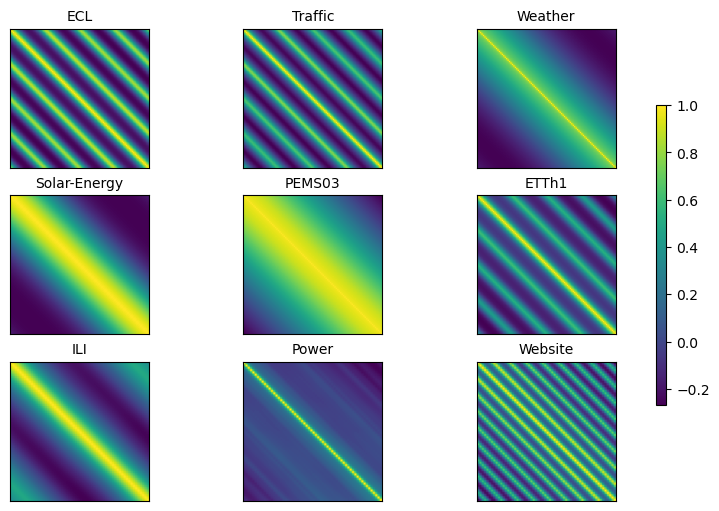

In [1]:
# plot

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Q_mat_files=[r'cov_mats\ecl\temp_corr_mat\Temp_corr_mat_electricity_96_ratio0.7.npy',
            r'cov_mats\Traffic\temp_corr_mat\Temp_corr_mat_traffic_96_ratio0.7.npy',
            r'cov_mats\Weather\temp_corr_mat\Temp_corr_mat_weather_96_ratio0.7.npy',
            r'cov_mats\Solar\temp_corr_mat\Temp_corr_mat_solar_AL_96_ratio0.7.npy',
            r'cov_mats\PEMS03\temp_corr_mat\Temp_corr_mat_PEMS03_96_ratio0.7.npy',
            r'cov_mats\ETTh1\temp_corr_mat\Temp_corr_mat_ETTh1_96_ratio0.7.npy',
            r'cov_mats\ILI\temp_corr_mat\Temp_corr_mat_ILI_60_ratio0.7.npy',
            r'cov_mats\power\temp_corr_mat\Temp_corr_mat_power_60_ratio0.7.npy',
            r'cov_mats\website\temp_corr_mat\Temp_corr_mat_website_60_ratio0.7.npy',]
titles=['ECL','Traffic', 'Weather','Solar-Energy','PEMS03','ETTh1','ILI','Power','Website']


fig, axes = plt.subplots(3, 3, figsize=(7, 5), constrained_layout=True)

cmap = "viridis"

for i, ax in enumerate(axes.flat):
    Q_mat=np.load(Q_mat_files[i])
    im = ax.imshow(Q_mat, cmap=cmap) 
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(titles[i], fontsize=10)

cbar_ax = fig.add_axes([0.99, 0.2, 0.015, 0.6])
fig.colorbar(im, cax=cbar_ax)


plt.savefig("Temp_corr_mat_3x3_.pdf", format="pdf", bbox_inches='tight')
plt.show()
